# USD Rates RV — PCA curve & fly relative value

Showcases `RVUtils.pca_rv`: PCA fair-value & residual rich/cheap, PC1/PC2-neutral fly weights, directionality, and risk buckets — on the SOFR swap curve (last ~1y EOD).

In [1]:
%matplotlib inline
import sys; sys.path.append("../../")
import datetime, pytz, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (15, 6); plt.rcParams["axes.grid"] = True
from RVUtils.plt_timeseries import make_secondary_axis_plot

NYC = pytz.timezone("America/New_York")
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from TB.FixedRateBondsTB import FixedRateBondsTB
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedValue
from TB.TimeseriesBuilder import TimeseriesBuilder

curve_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")
usts_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-RL")
ts = TimeseriesBuilder()
start = NYC.localize(datetime.datetime(2025, 6, 2, 17, 0))
end = NYC.localize(datetime.datetime(2026, 6, 17, 17, 0))
ROUTERS = {"IRS": IRSwapsTB(curve_mdp, show_tqdm=False), "FRB": FixedRateBondsTB(usts_mdp, show_tqdm=False)}
YRS = {"2y": 2, "3y": 3, "5y": 5, "7y": 7, "10y": 10, "20y": 20, "30y": 30}
MAT = {"CT2": 2, "CT3": 3, "CT5": 5, "CT7": 7, "CT10": 10, "CT20": 20, "CT30": 30}

def load(queries):
    return ts.get_timeseries(start=start, end=end, queries=queries, n_jobs=8, routers=ROUTERS)

def sofr(tenors):
    df = load([UnifiedQuery(curve="USD-SOFR-1D", tenor=t, value=UnifiedValue.IRS_RATE) for t in tenors])
    return df.rename(columns={f"USD-SOFR-1D {t} OUTRIGHT RATE": t for t in tenors})[list(tenors)]

def ust(cts):
    df = load([UnifiedQuery(cusip=c, value=UnifiedValue.FRB_YTM) for c in cts])
    return df.rename(columns={f"{c} OUTRIGHT YTM": c for c in cts})[list(cts)]

print("Setup OK. Window:", start.date(), "->", end.date())

Setup OK. Window: 2025-06-02 -> 2026-06-17


In [2]:
TENORS = ["2y","3y","5y","7y","10y","20y","30y"]
df_s = sofr(TENORS)
df_u = ust(["CT2","CT3","CT5","CT7","CT10","CT20","CT30"])
df_s.tail(3)

,2y,3y,5y,7y,10y,20y,30y
Date,,,,,,,
2026-06-15,3.922587,3.905793,3.912999,3.971968,4.075915,4.311921,4.273636
2026-06-16,3.906366,3.884688,3.885388,3.943336,4.045849,4.281858,4.246070
2026-06-17,3.905107,3.878312,3.876028,3.927737,4.029726,4.264042,4.224857


### Fit PCA on the SOFR curve (levels) — level / slope / curvature

In [3]:
from RVUtils.pca_rv import make_pca_rv_builder
(fit, fair_value, residual, fly_weights, curve_weights, directionality, risk_buckets, factor_corr_check, get_model) = make_pca_rv_builder(df_s, on="levels", n_factors=3, sort_by_tenor=False)
model = fit()
ev = model.explained_variance()
print("Explained variance PC1-3:", {k: round(float(v),4) for k,v in ev.head(3).items()})
model.loadings.iloc[:, :3].round(3)

Explained variance PC1-3: {'PC1': 0.9387, 'PC2': 0.0561, 'PC3': 0.0038}


,PC1,PC2,PC3
2y,0.444,-0.556,0.626
3y,0.458,-0.284,-0.179
5y,0.428,-0.020,-0.510
7y,0.394,0.107,-0.345
10y,0.346,0.215,-0.012
20y,0.272,0.453,0.317
30y,0.247,0.589,0.311


### PC1/PC2-neutral 2s5s10s fly: actual vs PCA fair value + residual z-score

PCA-neutral 2s5s10s weights: {'2y': -0.343, '5y': 1.0, '10y': -0.796}
Latest residual (+=belly cheap): 2.07 bp  | z65: 2.0


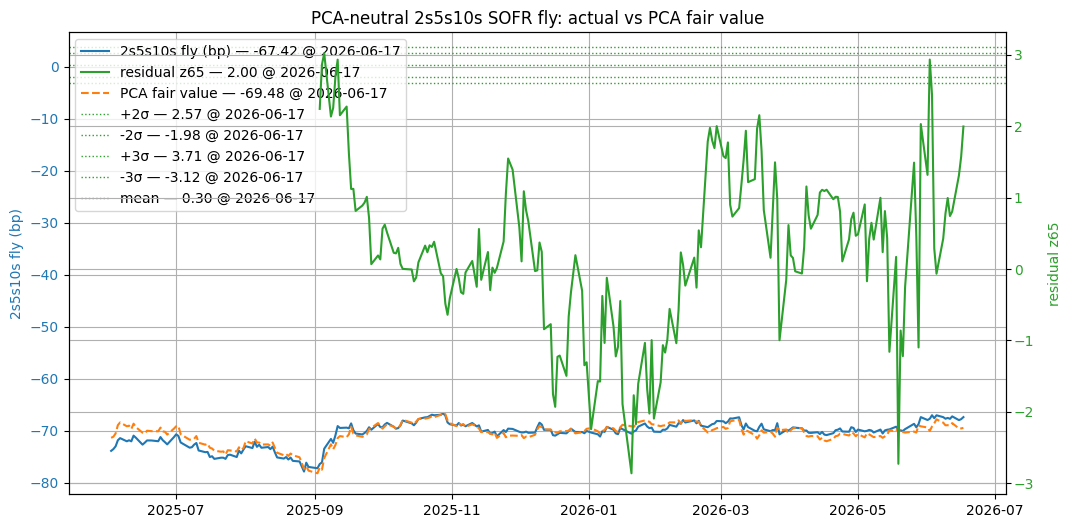

In [4]:
from RVUtils.plt_timeseries import make_secondary_axis_plot
w = fly_weights("2y","5y","10y")
print("PCA-neutral 2s5s10s weights:", {k: round(v,3) for k,v in w.items()})
res = residual(("2y","5y","10y"), weights=w)
fv = fair_value(k=3)
fly_raw = (w["2y"]*df_s["2y"] + w["5y"]*df_s["5y"] + w["10y"]*df_s["10y"]) * 100
fly_fv  = (w["2y"]*fv["2y"]   + w["5y"]*fv["5y"]   + w["10y"]*fv["10y"])   * 100
print("Latest residual (+=belly cheap):", round(res.last()*100,2), "bp  | z65:", round(res.zscore(65).iloc[-1],2))
plot, fig, ax, ax2, legend = make_secondary_axis_plot(engine="matplotlib", title="PCA-neutral 2s5s10s SOFR fly: actual vs PCA fair value")
plot(fly_raw.rename("2s5s10s fly (bp)"), which="left", indicators=[{"kind":"fair_value","series":fly_fv,"label":"PCA fair value"}])
plot(res.zscore(65).rename("residual z65"), which="right", indicators=[{"kind":"zbands","entry":2,"stop":3}])
legend(show_date=True, loc="upper left"); plt.show()

### Directionality (betas to level/slope) and risk-bucket check

In [5]:
dirn = directionality(("2y","5y","10y"), weights=w, drivers=("PC1","PC2"))
print("Fly betas to PC1/PC2:", {k: round(float(v),4) for k,v in dirn["betas"].items()})
ladder = pd.Series(0.0, index=TENORS); ladder["2y"]=w["2y"]; ladder["5y"]=w["5y"]; ladder["10y"]=w["10y"]
print("Fly PC exposures (PC1/PC2 ~ 0 by construction):", {k: round(float(v),4) for k,v in risk_buckets(ladder).head(3).items()})

Fly betas to PC1/PC2: {'PC1': -0.0, 'PC2': 0.0}
Fly PC exposures (PC1/PC2 ~ 0 by construction): {'PC1': -0.0, 'PC2': 0.0, 'PC3': -0.7155}


### UST CT2/CT10/CT30 PCA-fly residual (cross-check vs cash curve)

In [6]:
bu = make_pca_rv_builder(df_u.rename(columns={c:c for c in df_u.columns}), on="levels", n_factors=3, sort_by_tenor=False)
bu[0]()
wu = bu[3]("CT2","CT10","CT30")
resu = bu[2](("CT2","CT10","CT30"), weights=wu)
print("UST 2s10s30s PCA-neutral weights:", {k: round(v,3) for k,v in wu.items()})
print("Latest UST fly residual (+=belly cheap):", round(resu.last()*100,2), "bp | z65:", round(resu.zscore(65).iloc[-1],2))

UST 2s10s30s PCA-neutral weights: {'CT2': -0.389, 'CT10': 1.0, 'CT30': -0.685}
Latest UST fly residual (+=belly cheap): -0.47 bp | z65: 1.1
